In [1]:
# We need to re-setup everything in this new notebook
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# Device setup — use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # should print: Using device: cuda

# Paths
base_dir = r"C:\Users\SS\OneDrive\Desktop\University\Semester 6\pneumonia_project\chest_xray"

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(base_dir + r"\train", transform=train_transform)
val_dataset   = datasets.ImageFolder(base_dir + r"\val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(base_dir + r"\test",  transform=val_test_transform)

# Weighted sampler
targets = train_dataset.targets
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = torch.DoubleTensor([class_weights[t] for t in targets])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("✅ Setup complete! Ready to build the CNN.")

Using device: cuda
✅ Setup complete! Ready to build the CNN.


In [2]:
# ============================================================
# BUILDING THE CNN — Like stacking LEGO blocks!
#
# Each block does one job:
#   Conv2d     → scan the image for patterns (like a magnifying glass)
#   BatchNorm  → keeps numbers stable so training doesn't go crazy
#   ReLU       → removes negative numbers (keeps only useful signals)
#   MaxPool2d  → shrinks the image (keeps only the strongest features)
#   Dropout    → randomly turns off some neurons during training
#                (forces the AI not to memorize — like covering some
#                 answers during study so you actually learn!)
#   Linear     → the final "thinking" layer that makes the decision
# ============================================================

class PneumoniaCNN(nn.Module):

    def __init__(self):
        super(PneumoniaCNN, self).__init__()

        # ---- FEATURE EXTRACTOR (finds patterns in the X-ray) ----
        self.features = nn.Sequential(

            # Block 1 — finds basic edges
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 channels in → 32 feature maps
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 224x224 → 112x112

            # Block 2 — finds slightly complex shapes
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 → 64 feature maps
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 112x112 → 56x56

            # Block 3 — finds lung-level patterns
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 64 → 128 feature maps
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 56x56 → 28x28

            # Block 4 — finds complex infection features
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 28x28 → 14x14
        )

        # ---- CLASSIFIER (makes the final NORMAL/PNEUMONIA decision) ----
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # 256 × 14 × 14 = 50176 numbers → 1 long list
            nn.Linear(256 * 14 * 14, 512),  # 50176 → 512 (compress)
            nn.ReLU(),
            nn.Dropout(0.5),                 # randomly turn off 50% neurons (prevents memorizing)
            nn.Linear(512, 64),              # 512 → 64
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)                 # 64 → 2 outputs: [NORMAL score, PNEUMONIA score]
        )

    def forward(self, x):
        # This defines how data FLOWS through the network
        x = self.features(x)      # extract features
        x = self.classifier(x)    # make decision
        return x


# Create the model and move it to GPU
model = PneumoniaCNN().to(device)
print(model)
print(f"\n✅ CNN created on: {next(model.parameters()).device}")

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [3]:
# ============================================================
# Let's count how many "knobs" our AI has to tune
# Each parameter is a number the AI adjusts during training
# More parameters = more powerful (but needs more data & time)
# ============================================================

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"\nIn human terms: the AI has {trainable:,} little knobs to tune!")
print("During training, it adjusts ALL of them to get better at detecting pneumonia.")

Total parameters    : 26,112,962
Trainable parameters: 26,112,962

In human terms: the AI has 26,112,962 little knobs to tune!
During training, it adjusts ALL of them to get better at detecting pneumonia.


In [4]:
# ============================================================
# LOSS FUNCTION — the "score" that tells AI how wrong it was
#   CrossEntropyLoss is standard for classification
#   Lower loss = AI is more correct
#
# OPTIMIZER — the strategy AI uses to improve itself
#   Adam is the most popular — it's smart about adjusting each knob
#
# LEARNING RATE — how big each adjustment step is
#   Too big  → AI overshoots and never learns properly
#   Too small → AI learns but very slowly
#   0.001 is a safe starting point
#
# SCHEDULER — automatically reduces learning rate over time
#   Like slowing down as you get closer to your destination
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Reduce learning rate by half if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

print("✅ Loss function : CrossEntropyLoss")
print("✅ Optimizer     : Adam (lr=0.001)")
print("✅ Scheduler     : ReduceLROnPlateau (patience=3)")

✅ Loss function : CrossEntropyLoss
✅ Optimizer     : Adam (lr=0.001)
✅ Scheduler     : ReduceLROnPlateau (patience=3)


C:\Users\SS\OneDrive\Desktop\University\Semester 6\pneumonia_project\venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [5]:
# ============================================================
# THE TRAINING LOOP — This is where the AI actually LEARNS
#
# One "epoch" = the AI sees ALL training images once
# We do 20 epochs = 20 full rounds of studying
#
# Each epoch:
#   1. Feed batch of 32 images → AI guesses
#   2. Calculate how wrong the guess was (loss)
#   3. Backpropagate — figure out which knobs caused the error
#   4. Optimizer adjusts those knobs slightly
#   5. Repeat for all 163 batches
# ============================================================

EPOCHS = 20
best_val_loss = float('inf')  # track the best model

# Lists to store history for plotting later
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

for epoch in range(EPOCHS):

    # ---- TRAINING PHASE ----
    model.train()   # tell model "we are training" (enables dropout)
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, labels = images.to(device), labels.to(device)  # send to GPU

        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)        # forward pass: AI makes predictions
        loss = criterion(outputs, labels)  # how wrong was it?
        loss.backward()                # backprop: who caused this error?
        optimizer.step()               # adjust the knobs

        train_loss    += loss.item()
        predicted      = outputs.argmax(dim=1)  # pick the higher scoring class
        train_correct += (predicted == labels).sum().item()
        train_total   += labels.size(0)

    # ---- VALIDATION PHASE ----
    model.eval()    # tell model "we are testing" (disables dropout)
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():   # don't calculate gradients (saves memory)
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    # Calculate averages
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc      = 100 * train_correct / train_total
    val_acc        = 100 * val_correct   / val_total

    # Save history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    # Step the scheduler
    scheduler.step(avg_val_loss)

    print(f"\nEpoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save the best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_cnn_scratch.pth")
        print(f"   💾 Best model saved!")

print("\n🎉 Training complete!")

Epoch 1/20 [Train]: 100%|███████████████████████████████████████████████████████████████████████████| 163/163 [07:03<00:00,  2.60s/it]



Epoch 01/20 | Train Loss: 0.5502 | Train Acc: 81.71% | Val Loss: 1.1038 | Val Acc: 62.50%
   💾 Best model saved!


Epoch 2/20 [Train]: 100%|███████████████████████████████████████████████████████████████████████████| 163/163 [06:24<00:00,  2.36s/it]



Epoch 02/20 | Train Loss: 0.2397 | Train Acc: 91.26% | Val Loss: 0.9918 | Val Acc: 68.75%
   💾 Best model saved!


Epoch 3/20 [Train]: 100%|███████████████████████████████████████████████████████████████████████████| 163/163 [05:55<00:00,  2.18s/it]


...


Epoch 18/20 | Train Loss: 0.0931 | Train Acc: 97.03% | Val Loss: 0.3740 | Val Acc: 81.25%


Epoch 19/20 [Train]: 100%|██████████████████████████████████████████████████████████████████████████| 163/163 [03:33<00:00,  1.31s/it]



Epoch 19/20 | Train Loss: 0.0726 | Train Acc: 97.51% | Val Loss: 0.2084 | Val Acc: 93.75%
   💾 Best model saved!


Epoch 20/20 [Train]: 100%|██████████████████████████████████████████████████████████████████████████| 163/163 [03:31<00:00,  1.30s/it]



Epoch 20/20 | Train Loss: 0.0587 | Train Acc: 98.08% | Val Loss: 0.2743 | Val Acc: 93.75%

🎉 Training complete!


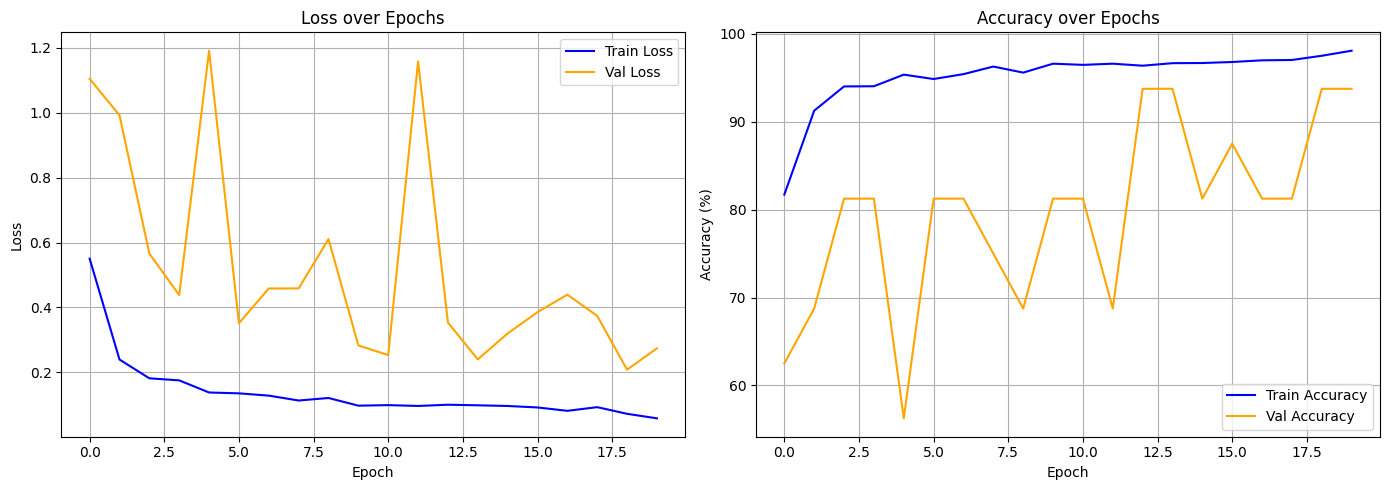

✅ Learning curves saved!


In [6]:
# ============================================================
# LEARNING CURVES — show how the AI improved over time
# Good training looks like:
#   Loss going DOWN  📉
#   Accuracy going UP 📈
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'],   label='Val Loss',   color='orange')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
ax2.plot(history['val_acc'],   label='Val Accuracy',   color='orange')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("cnn_scratch_training.png", dpi=150)
plt.show()
print("✅ Learning curves saved!")